# SVGP experiments

Fitting the areal event-count model for one place, starting with Laos.

In [1]:
%load_ext autoreload
%autoreload 2

# Set before anything builds a graph: MLX has no float64 on the GPU, and PyMC reads floatX when it
# makes a model's value variables.
import pytensor

pytensor.config.floatX = "float32"

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import preliz as pz
import ptgp
import pymc as pm
import pytensor.tensor as pt

from better_optimize import minimize
from matplotlib.colors import LogNorm
from matplotlib.path import Path as MplPath
from ptgp import FitResult
from ptgp.gp import SVGP, init_variational_params
from ptgp.inducing import Points
from ptgp.kernels import Matern32
from ptgp.likelihoods import Poisson
from ptgp.optim.training import compile_scipy_objective, compile_training_step, get_trained_params
from pytensor import shared
from shapely.geometry import box
from sklearn.cluster import KMeans
from tqdm.auto import trange

from climate_risk.config.schema import EventFilters
from climate_risk.data.gadm import load_admin_units, load_units_in_country
from climate_risk.data.ghsl import population_on_cells
from climate_risk.data.model_frame import event_windows
from climate_risk.data.placement import resolve_location_text
from climate_risk.data_functions.emdat_processing import event_filter, event_geography, load_emdat_events
from climate_risk.data_functions.rivers_data_loader import load_rivers_data
from climate_risk.data_functions.shapefiles_data_loader import load_shapefile
from climate_risk.geo.crs import to_km
from climate_risk.geo.distance import get_distance_to
from climate_risk.geo.raster import assign_cells_to_units, build_cell_grid, dissolve_place_boundary
from climate_risk.models.aggregation import Aggregation, build_aggregation
from climate_risk.models.aggregated_poisson import VARIANCE_FLOOR, latent_moments
from climate_risk.models.areal import windowed_poisson_elbo
from climate_risk.models.frame import window_aggregation
from climate_risk.plotting import configure_plot_style

FLOATX = pytensor.config.floatX

pz.rcParams["plots.show_plot"] = False
configure_plot_style()

In [2]:
CACHE = (Path.cwd().parents[1] if Path.cwd().name == "geo_damage_model" else Path.cwd()) / "data"

ISO = "LAO"
RESOLUTION_KM = 5.0
EPOCH = 2020

# Floods and storms, which are the hazards distance to river and distance to coast describe. The
# spelling is the wire value EM-DAT processing writes.
HAZARD_CLASS = "Hydrometereological"

## The grid

Cells carry the exposure weight the observation operator multiplies by.

In [3]:
units = load_units_in_country(iso=ISO, level=1, cache_dir=CACHE).assign(ISO_A3=ISO)
boundary = dissolve_place_boundary(units)
grid = build_cell_grid(boundary, resolution_km=RESOLUTION_KM)

people = population_on_cells(grid, EPOCH, CACHE)

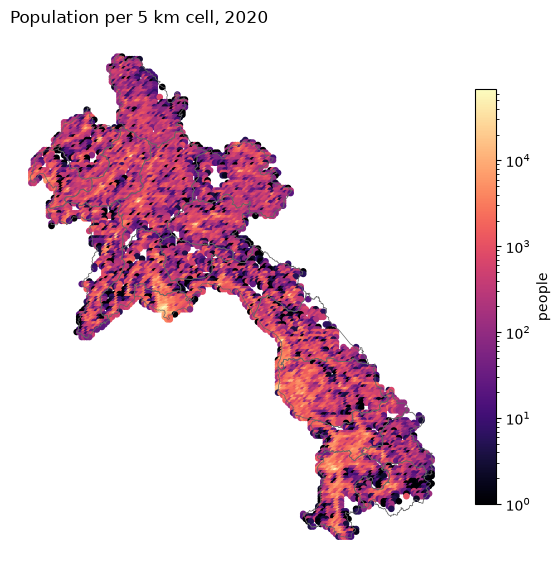

In [4]:
figure, ax = plt.subplots(figsize=(5.5, 7))

cells = grid.cells.assign(people=people)
cells.plot(ax=ax, column="people", cmap="magma", markersize=14, norm=LogNorm(vmin=1))
people_layer = ax.collections[-1]
units.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

ax.set_title(f"Population per {RESOLUTION_KM:.0f} km cell, {EPOCH}", loc="left")
ax.set_axis_off()
figure.colorbar(people_layer, ax=ax, label="people", shrink=0.6)
plt.show()

## What the model sees

Population is the exposure the operator weights by; the distances are the covariates the linear predictor gets.

In [4]:
rivers = load_rivers_data(CACHE)
coastline = load_shapefile("coastline", CACHE)

to_river = to_km(get_distance_to(rivers, points=grid.cells)["distance_to_closest"])
to_coast = to_km(get_distance_to(coastline.boundary, points=grid.cells)["distance_to_closest"])

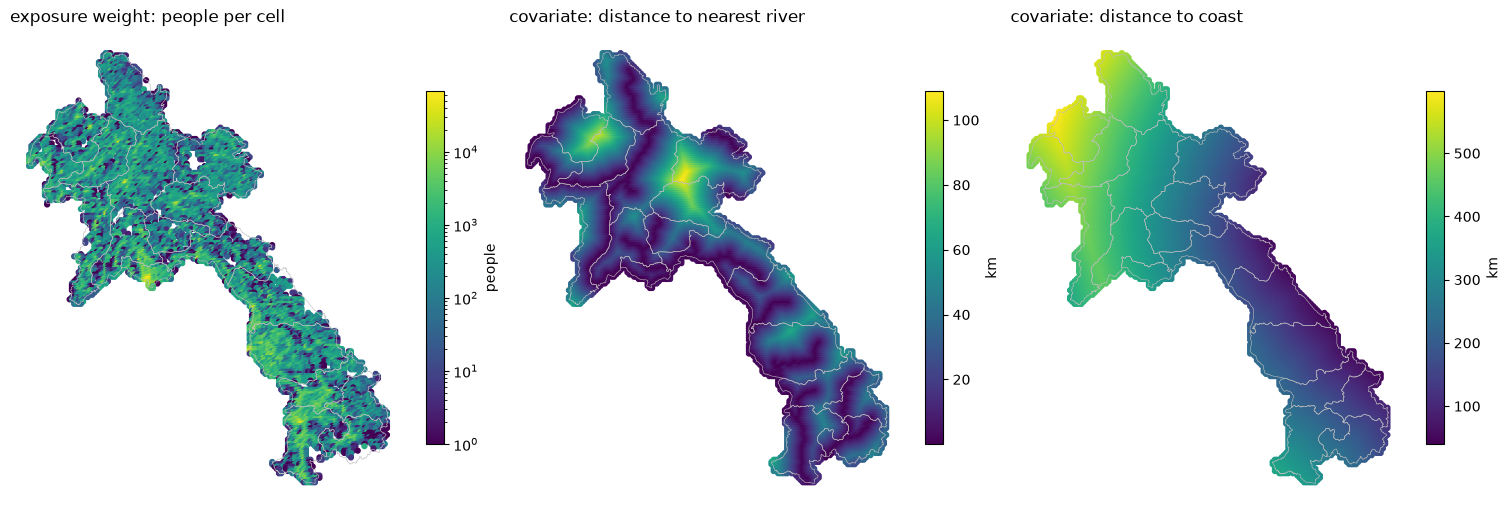

In [6]:
panels = [
    ("exposure weight: people per cell", people, LogNorm(vmin=1), "people"),
    ("covariate: distance to nearest river", to_river.to_numpy(), None, "km"),
    ("covariate: distance to coast", to_coast.to_numpy(), None, "km"),
]

figure, axes = plt.subplots(1, 3, figsize=(15, 6.5))

for ax, (title, values, norm, unit) in zip(axes, panels, strict=True):
    grid.cells.assign(value=values).plot(ax=ax, column="value", cmap="viridis", markersize=12, norm=norm)
    value_layer = ax.collections[-1]
    units.boundary.plot(ax=ax, color="0.75", linewidth=0.4)

    ax.set_title(title, loc="left")
    ax.set_axis_off()
    figure.colorbar(value_layer, ax=ax, label=unit, shrink=0.55)

plt.show()

## Events and their windows

Each event is one observation, seen through whatever units its sources reached.

In [5]:
workbook = load_emdat_events(CACHE)
events = workbook.filter(
    event_filter(EventFilters()) & (pl.col("ISO") == ISO) & (pl.col("disaster_class") == HAZARD_CLASS)
)

from_text, text_resolution = resolve_location_text(events, CACHE)
geography = event_geography(events, from_text=from_text, text_resolution=text_resolution)

windows = event_windows(events, geography)

In [7]:
# The sources reach whatever level they reach, so the coverage is read at every level the geography
# names. A window finer than the coverage matches no cell, and its event is dropped.
named_units = geography.select("gid", "admin_level").drop_nulls().unique()
coverage = assign_cells_to_units(grid, load_admin_units(list(named_units.iter_rows()), CACHE))

observations = window_aggregation(windows, coverage, grid, cell_weights=people)

## Cell-years

The field is three-dimensional. A quadrature point is a cell in a year, and an event lights up its window in the year it happened. Distances are logged before standardizing: they are positive and skewed, and the predictor is log-linear.

In [6]:
def standardized(values: np.ndarray) -> np.ndarray:
    return (values - values.mean()) / values.std()


COVARIATE_NAMES = ["log km to river", "log km to coast"]

In [8]:
years = np.arange(windows["year"].min(), windows["year"].max() + 1)
n_cells, n_years = len(grid.cells), len(years)
lon, lat = grid.cells["lon"].to_numpy(), grid.cells["lat"].to_numpy()

# One row per cell-year, cells varying fastest, so a column is year_index * n_cells + cell_index.
coordinates = np.column_stack(
    [np.tile(lon, n_years), np.tile(lat, n_years), np.repeat(years, n_cells)]
).astype(FLOATX)
design = np.tile(
    np.column_stack([standardized(np.log1p(to_river.to_numpy())), standardized(np.log1p(to_coast.to_numpy()))]),
    (n_years, 1),
).astype(FLOATX)
cell_year_weights = np.tile(people, n_years).astype(FLOATX)

In [9]:
year_index = {year: position for position, year in enumerate(years)}
year_of_event = dict(zip(windows["DisNo."], windows["year"], strict=True))

# Events that reach no cell are absent from the operator, so the year comes from a lookup on the
# row label.
offset_of_event = np.array([year_index[year_of_event[disno]] for disno in observations.units]) * n_cells

spatial_overlaps = observations.matrix.tocoo()
observations_3d = Aggregation(
    units=observations.units,
    rows=spatial_overlaps.row,
    columns=spatial_overlaps.col + offset_of_event[spatial_overlaps.row],
    weights=spatial_overlaps.data,
    n_cells=n_cells * n_years,
)
region_3d = build_aggregation(unit_of_cell=["place"] * (n_cells * n_years), weights=cell_year_weights)

counts = np.ones(observations_3d.n_units, dtype=FLOATX)

## The fit

Inducing points, then the priors, then maximum a posteriori.

In [10]:
N_INDUCING = 200

# KMeans minimizes plain Euclidean distance and the year axis spans six times what lon and lat do,
# so clustering the raw coordinates partitions time and leaves every centroid at the same place.
axis_scale = coordinates.std(axis=0)
placement = KMeans(n_clusters=N_INDUCING, random_state=0, n_init=10).fit(
    coordinates / axis_scale, sample_weight=cell_year_weights + 1.0
)
inducing = placement.cluster_centers_ * axis_scale

In [11]:
KERNEL_DIMS = [0, 1, 2]

# The regression mean is indexed to whatever rows it is handed, so the covariates ride in the design
# matrix on dimensions the kernel does not act over. A mean closing over an array of the lattice's
# length could only ever be evaluated at the whole lattice.
features = np.column_stack([coordinates, design]).astype(FLOATX)

# active_dims slices the inducing points too, so their padding is never read.
inducing_features = np.column_stack([inducing, np.zeros((N_INDUCING, design.shape[1]))]).astype(FLOATX)

In [12]:
def build_model() -> tuple[pm.Model, SVGP]:
    """
    The areal GP: a regression mean in the distance covariates under a Matern 3/2 field.

    Returns
    -------
    model : Model
        The PyMC model holding the hyperparameter priors.
    svgp : SVGP
        The sparse variational field defined over it.
    """    
    with pm.Model() as model:
        coefficients = pm.Normal("coefficients", mu=0.0, sigma=1.0, shape=(design.shape[1],))
        intercept = pm.Normal("intercept", mu=-10.0, sigma=5.0)

        # The field is a log-scale multiplier on the rate, so this range is a residual swing
        # between about 1.2x and 2.7x either way.
        amplitude = pz.maxent(pz.Gamma(), lower=0.2, upper=1.0, mass=0.9).to_pymc("amplitude")
        # Degrees. A cell is a quarter of one and the country is ten tall, so this spans a
        # sub-provincial patch up to a synoptic weather system.
        spatial = pz.maxent(pz.InverseGamma(), lower=0.5, upper=4.0, mass=0.9).to_pymc("spatial_lengthscale")
        # Years: interannual at the low end, a multidecadal climate regime at the high.
        temporal = pz.maxent(pz.InverseGamma(), lower=2.0, upper=20.0, mass=0.9).to_pymc("temporal_lengthscale")

        kernel = Matern32(
            input_dim=features.shape[1],
            ls=pt.stack([spatial, spatial, temporal]),
            active_dims=KERNEL_DIMS,
        )
        svgp = SVGP(
            kernel=amplitude**2 * kernel,
            likelihood=Poisson(),
            mean=lambda batch: intercept + pt.dot(batch[:, len(KERNEL_DIMS) :], coefficients),
            inducing_variable=Points(Z=inducing_features),
            variational_params=init_variational_params(N_INDUCING),
            whiten=True,
        )

    return model, svgp

In [13]:
MAXITER = 2000
TOLERANCE = 1e-16
COMPILE_MODE = "MLX"

MLX_CACHE_LIMIT = 2 * 1024**3
MLX_MEMORY_LIMIT = 8 * 1024**3


def guard_mlx_memory():
    """Cap MLX's allocator so an oversized fit raises instead of taking the machine down.

    Every batch is a different size, so MLX caches a fresh set of buffers each step and the cache
    grows without bound; it is a cache, so capping it costs only re-allocation. The memory limit
    turns an out-of-memory into a Python error rather than a dead kernel.
    """
    if COMPILE_MODE != "MLX":
        return

    import mlx.core as mx

    mx.set_cache_limit(MLX_CACHE_LIMIT)
    mx.set_memory_limit(MLX_MEMORY_LIMIT)


def fit_field() -> tuple[SVGP, FitResult]:
    """
    Fit the areal GP by maximum a posteriori, on the whole lattice at once.

    Returns
    -------
    svgp : SVGP
        The fitted field.
    result : FitResult
        Trained parameters and the optimizer's own result, ready for :func:`ptgp.predict`.
    """
    guard_mlx_memory()
    model, svgp = build_model()

    with model:

        def objective(gp, cell_features, window_counts):
            return windowed_poisson_elbo(
                gp, cell_features, window_counts, observations_3d, region_3d, n_draws=16, seed=1
            )

        loss_and_grad, start, unpack, shared_params, shared_extras = compile_scipy_objective(
            objective,
            svgp,
            pt.matrix("X", shape=(None, features.shape[1])),
            pt.vector("y", shape=(None,)),
            model=model,
            compile_kwargs={"mode": COMPILE_MODE},
        )

        # Scipy needs numpy; the MLX linker hands back its own array type.
        def loss_and_grad_outer(*args, **kwargs):
            loss, grads = loss_and_grad(*args, **kwargs)
            return np.array(loss), np.array(grads)

        def descend(position):
            return minimize(
                loss_and_grad_outer,
                position,
                args=(features, counts),
                method="L-BFGS-B",
                tol=TOLERANCE,
                maxiter=MAXITER,
            )

        # L-BFGS-B stops on its relative-reduction test with the gradient still far from zero.
        # Restarting resets the curvature memory, so restart until one buys nothing.
        settled = descend(start)
        while settled.nit > 0:
            settled = descend(settled.x)

        unpack(settled.x)
        trained = get_trained_params(model, shared_params)

    return svgp, FitResult(
        result=settled,
        params=trained,
        shared_params=shared_params,
        shared_extras=tuple(shared_extras),
        model=model,
    )

In [17]:
svgp, result = fit_field()
trained = result.params

pd.Series(
    {
        **dict(zip(COVARIATE_NAMES, trained["coefficients"], strict=True)),
        "intercept": trained["intercept"],
        "amplitude": trained["amplitude"],
        "spatial lengthscale (deg)": trained["spatial_lengthscale"],
        "temporal lengthscale (yr)": trained["temporal_lengthscale"],
    },
    name="posterior mean",
).to_frame().round(3)

Error in callback <bound method AutoreloadMagics.pre_run_cell of <IPython.extensions.autoreload.AutoreloadMagics object at 0x105456480>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 36e81f2c0, raw_cell="svgp, result = fit_field()
trained = result.params.." transformed_cell="svgp, result = fit_field()
trained = result.params.." store_history=True silent=False shell_futures=True cell_id=None cell_meta={}>,),kwargs {}:


KeyboardInterrupt: 


KeyboardInterrupt



In [27]:
posterior_mean, posterior_variance = ptgp.predict(svgp, features, result)
intensity = np.exp(posterior_mean + posterior_variance / 2.0)

# The restart loop exits on a no-op call, so `success` and `nit` describe that call and not the
# fit. The gradient is what says whether the fit is at an optimum.
pd.Series(
    {
        "largest gradient": float(np.abs(result.result.jac).max()),
        "objective": float(result.result.fun),
        "expected events over Laos": float(region_3d.aggregate(intensity)[0]),
        "events observed": float(observations_3d.n_units),
    },
    name="value",
).to_frame().round(4)

,value
largest gradient,0.03
objective,-152.69
expected events over Laos,41.62
events observed,41.00


## The fitted field

One slice per panel. Inducing points are sized by how much they inform the year shown, and the events are the windows that were observed in it.

In [17]:
def boundary_path(geometry) -> MplPath:
    """A matplotlib path over a (multi)polygon's rings, for clipping a filled contour to the place."""
    vertices, codes = [], []

    for polygon in getattr(geometry, "geoms", [geometry]):
        for ring in [polygon.exterior, *polygon.interiors]:
            ring_coordinates = np.asarray(ring.coords)
            vertices.append(ring_coordinates)
            codes.append([MplPath.MOVETO, *[MplPath.LINETO] * (len(ring_coordinates) - 2), MplPath.CLOSEPOLY])

    return MplPath(np.concatenate(vertices), np.concatenate(codes))

In [18]:
PANEL_YEARS = [int(years[0]), int(years[n_years // 2]), int(years[-1])]

# The window is the ground the operator integrates over: the cells the event reaches. The lattice
# is regular in degrees, and the pad overlaps neighbors so no sliver survives the union.
cells_of_event = observations_3d.matrix.tocsr()
year_of_row = np.array([year_of_event[disno] for disno in observations_3d.units])

half_lon = np.diff(np.unique(lon))[0] / 2 + 1e-6
half_lat = np.diff(np.unique(lat))[0] / 2 + 1e-6
footprints = gpd.GeoSeries(
    [box(x - half_lon, y - half_lat, x + half_lon, y + half_lat) for x, y in zip(lon, lat, strict=True)],
    crs=grid.cells.crs,
)
clip = boundary_path(boundary.geometry.iloc[0])


def draw_field(ax, latent_year, levels, year):
    """One year's latent surface, clipped to the place, with that year's event windows on top."""
    field = ax.tricontourf(lon, lat, latent_year, levels=levels, cmap="magma", extend="both")
    field.set_clip_path(clip, transform=ax.transData)
    units.boundary.plot(ax=ax, color="0.35", linewidth=0.4)

    observed = np.flatnonzero(year_of_row == year)
    for row in observed:
        reached = cells_of_event[row].tocoo().col % n_cells
        gpd.GeoSeries([footprints.iloc[reached].union_all()], crs=grid.cells.crs).boundary.plot(
            ax=ax, color="#39ff88", linewidth=1.4
        )

    ax.set_axis_off()

    return field, len(observed)

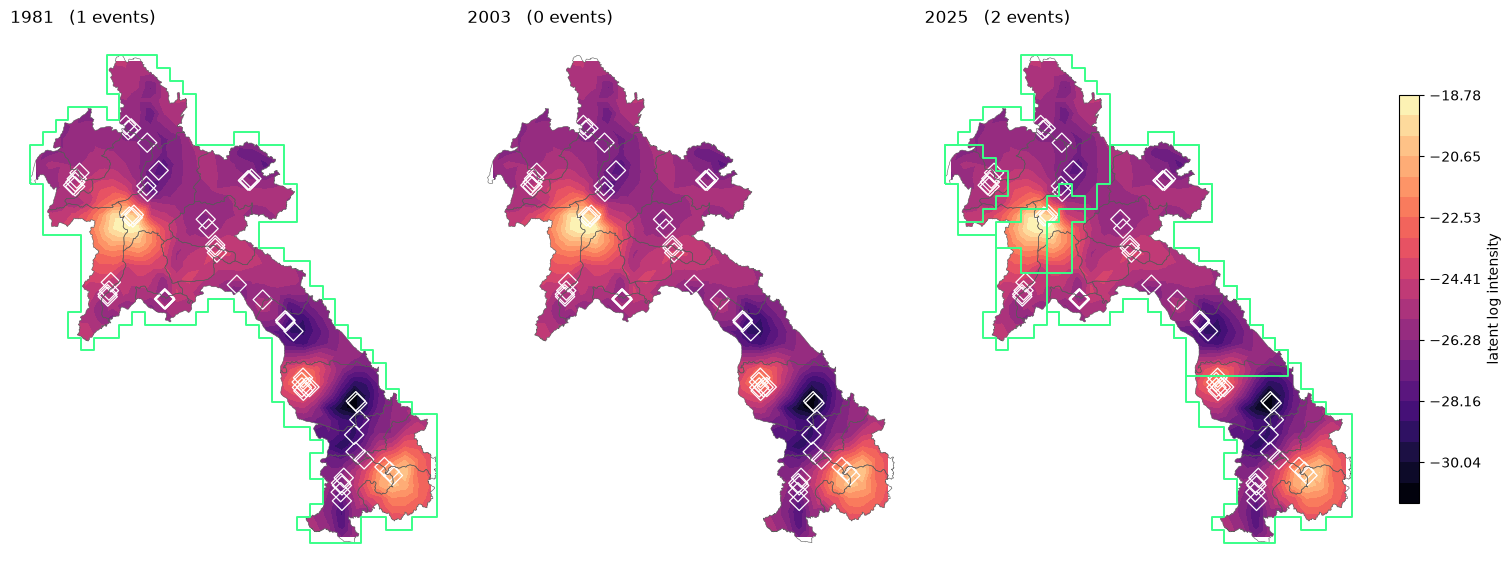

In [29]:
latent = posterior_mean.reshape(n_years, n_cells)
shown = latent[[year_index[year] for year in PANEL_YEARS]]
levels = np.linspace(shown.min(), shown.max(), 21)

figure, axes = plt.subplots(1, 3, figsize=(15, 7.5), sharex=True, sharey=True)

for ax, year in zip(axes, PANEL_YEARS, strict=True):
    field, n_observed = draw_field(ax, latent[year_index[year]], levels, year)

    # An inducing point sits at a year as well as a place, so it informs this slice by how near it
    # is, at the temporal lengthscale the fit settled on.
    informs = np.exp(-0.5 * ((inducing[:, 2] - year) / trained["temporal_lengthscale"]) ** 2)
    ax.scatter(
        inducing[:, 0],
        inducing[:, 1],
        s=6 + 90 * informs,
        marker="D",
        facecolor="none",
        edgecolor="white",
        linewidth=0.9,
    )
    ax.set_title(f"{year}   ({n_observed} events)", loc="left")

figure.colorbar(field, ax=axes, label="latent log intensity", shrink=0.55, pad=0.02)
plt.show()

## Minibatching

The objective is a sum over event windows minus a sum over quadrature cells, so both terms subsample without bias. A window's contribution is nonlinear in its own total, so a sampled window brings all of its cells; the region term is a plain sum, so its cells are sampled directly.

$$\begin{aligned}
\widehat{\mathcal{L}} &= \frac{|A|}{|A_b|} \sum_{a \in A_b} y_a \, \mathbb{E}_q[\log \Lambda_a] \\
&\quad - \frac{|R|}{|R_b|} \sum_{i \in R_b} w_i \, \mathbb{E}_q[e^{f_i}] \\
&\quad - \mathrm{KL}\left[q(u) \,\|\, p(u)\right]
\end{aligned}$$

The covariates move into the design matrix the kernel is handed, on dimensions it does not act over, so the regression mean can be indexed to a batch.

In [14]:
DRAWS_PER_STEP = 16

# A country-tier window reaches every cell of its year, so N_WINDOWS of them bounds what the
# windows claim of a batch. BATCH_CELLS has to exceed that and leave room to sample the rest, and
# holding it fixed gives MLX one buffer size to reuse instead of a fresh set every step.
N_WINDOWS = 2
BATCH_CELLS = 24_000

# The compiled step takes only the batch's features and counts as arguments, so everything else the
# batch stands for -- its operator, its scale factor, and its noise -- travels in shared variables
# the sampler writes before each call.
batch_rows = shared(np.zeros(1, dtype="int64"), name="batch_rows")
batch_window_cells = shared(np.zeros(1, dtype="int64"), name="batch_window_cells")
batch_window_weights = shared(np.zeros(1, dtype=FLOATX), name="batch_window_weights")
batch_region_weights = shared(np.zeros(BATCH_CELLS, dtype=FLOATX), name="batch_region_weights")
window_scale = shared(np.array(1.0, dtype=FLOATX), name="window_scale")

# Redrawn every step. Fixed draws would make the objective a deterministic surrogate for Adam to
# chase rather than an unbiased gradient, and a draw pinned to a position would mean a different
# cell each step anyway.
inducing_draws = shared(np.zeros((N_INDUCING, DRAWS_PER_STEP), dtype=FLOATX), name="inducing_draws")
cell_draws = shared(np.zeros((BATCH_CELLS, DRAWS_PER_STEP), dtype=FLOATX), name="cell_draws")

window_operator = observations_3d.matrix.tocsr()
n_quadrature = observations_3d.n_cells


def load_batch(rng, n_windows):
    """
    Draw a minibatch of exactly ``BATCH_CELLS`` cells and write it into the shared variables.

    A sampled window's contribution is nonlinear in its own total, so it brings every cell it
    reaches. Those cells then enter the region term at their own weight -- exactly, not sampled --
    and the rest of the budget is filled from the ground no window covers, carrying the scale that
    makes it stand for all of it.

    Parameters
    ----------
    rng : Generator
        Source of the samples and the step's noise.
    n_windows : int
        Event windows in the batch, sampled without replacement.

    Returns
    -------
    batch_features : ndarray
        Shape ``(BATCH_CELLS, n_features)``.
    batch_counts : ndarray
        Shape ``(n_windows,)``, the counts of the sampled windows, in their operator's row order.
    """
    windows = rng.choice(observations_3d.n_units, size=n_windows, replace=False)
    overlaps = window_operator[windows].tocoo()
    window_cells = np.unique(overlaps.col)

    n_sampled = BATCH_CELLS - window_cells.size
    if n_sampled < 1:
        raise ValueError(
            f"{n_windows} windows reach {window_cells.size} cells, leaving no room in a batch of "
            f"{BATCH_CELLS}. Raise BATCH_CELLS or lower n_windows."
        )

    # Drawing this many guarantees `n_sampled` survive even if every window cell comes up.
    drawn = rng.choice(n_quadrature, size=n_sampled + window_cells.size, replace=False)
    sampled = drawn[~np.isin(drawn, window_cells, assume_unique=True)][:n_sampled]

    # Window cells first and sorted, so an overlap's column is its position by binary search.
    cells = np.concatenate([window_cells, sampled])
    region_weights = cell_year_weights[cells].astype(FLOATX)
    region_weights[window_cells.size :] *= (n_quadrature - window_cells.size) / n_sampled

    batch_rows.set_value(overlaps.row.astype("int64"))
    batch_window_cells.set_value(np.searchsorted(window_cells, overlaps.col).astype("int64"))
    batch_window_weights.set_value(overlaps.data.astype(FLOATX))
    batch_region_weights.set_value(region_weights)
    window_scale.set_value(np.array(observations_3d.n_units / n_windows, dtype=FLOATX))

    inducing_draws.set_value(rng.standard_normal((N_INDUCING, DRAWS_PER_STEP), dtype=FLOATX))
    cell_draws.set_value(rng.standard_normal((BATCH_CELLS, DRAWS_PER_STEP), dtype=FLOATX))

    return features[cells], counts[windows]

In [23]:
CHECK_DRAWS = 200

rng = np.random.default_rng(0)
sizes, region_totals = [], []
for _ in range(CHECK_DRAWS):
    batch_features, _ = load_batch(rng, N_WINDOWS)
    sizes.append(batch_features.shape[0])
    region_totals.append(float(batch_region_weights.get_value().sum()))

region_totals = np.array(region_totals)
truth = float(cell_year_weights.sum())
monte_carlo_error = 1.96 * region_totals.std(ddof=1) / np.sqrt(CHECK_DRAWS)

pd.Series(
    {
        "distinct batch sizes": float(len(set(sizes))),
        "cells per batch": float(sizes[0]),
        "region weight, whole lattice": truth,
        "region weight, batch estimate": region_totals.mean(),
        "bias (%)": 100 * (region_totals.mean() / truth - 1),
        "95% Monte Carlo error (%)": 100 * monte_carlo_error / truth,
    },
    name="value",
).to_frame()

,value
distinct batch sizes,1.00
cells per batch,24000.00
"region weight, whole lattice",330583040.00
"region weight, batch estimate",331061847.84
bias (%),0.14
95% Monte Carlo error (%),0.32


In [15]:
def minibatch_elbo(gp, batch_features, batch_counts):
    """The objective on the batch the shared variables hold, rescaled to stand for the whole sum."""
    mean, independent_variance, factor = latent_moments(gp, batch_features)

    spread = pt.sqrt(pt.clip(independent_variance, VARIANCE_FLOOR, np.inf))
    field = mean[:, None] + factor @ inducing_draws + spread[:, None] * cell_draws

    # Shifted before exponentiating, so a window whose cells all underflow early in training does
    # not take the log of zero.
    shift = pt.max(field, axis=0)
    contributions = batch_window_weights[:, None] * pt.exp(field - shift)[batch_window_cells]
    totals = pt.inc_subtensor(pt.zeros((batch_counts.shape[0], DRAWS_PER_STEP))[batch_rows], contributions)
    log_intensity = pt.mean(pt.log(totals) + shift, axis=1)

    # Every cell of the batch enters the region term; the weights carry the scale that makes the
    # sampled ones stand for the ground no window covers.
    log_scaled = mean + (independent_variance + pt.sum(factor**2, axis=1)) / 2.0
    region_shift = pt.max(log_scaled)
    over_region = pt.dot(batch_region_weights, pt.exp(log_scaled - region_shift)) * pt.exp(region_shift)

    window_term = window_scale * pt.sum(batch_counts * log_intensity)

    return window_term - over_region - gp.prior_kl()

In [16]:
def train_minibatch(n_steps, *, n_windows, learning_rate=0.01, seed=0):
    """
    Fit the areal GP with Adam on minibatches.

    Parameters
    ----------
    n_steps : int
        Optimizer steps to take.
    n_windows : int
        Event windows per batch. A country-tier window reaches every cell of its year, so this
        bounds how much of a batch the windows claim and how much is left to sample.
    learning_rate : float, optional
        Adam step size. Default 0.01.
    seed : int, optional
        Seed for the batch sampler and the step noise. Default 0.

    Returns
    -------
    svgp : SVGP
        The fitted field.
    result : FitResult
        Trained parameters, carrying the per-step loss on ``result.result``.
    """
    guard_mlx_memory()
    model, svgp = build_model()
    rng = np.random.default_rng(seed)

    with model:
        step, shared_params, shared_extras = compile_training_step(
            minibatch_elbo,
            svgp,
            pt.matrix("X", shape=(BATCH_CELLS, features.shape[1])),
            pt.vector("y", shape=(n_windows,)),
            model=model,
            learning_rate=learning_rate,
            compile_kwargs={"mode": COMPILE_MODE},
        )

        losses = np.empty(n_steps)
        progress = trange(n_steps, desc="adam")
        for position in progress:
            losses[position] = step(*load_batch(rng, n_windows))
            if position % 25 == 0:
                progress.set_postfix(loss=f"{losses[position]:.1f}")

        trained = get_trained_params(model, shared_params)

    return svgp, FitResult(
        result=losses, params=trained, shared_params=shared_params, shared_extras=tuple(shared_extras), model=model
    )

In [26]:
import mlx.core as mx

mx.clear_cache()
mx.reset_peak_memory()

minibatch_svgp, minibatch_result = train_minibatch(400, n_windows=N_WINDOWS, learning_rate=0.02)
minibatch_trained = minibatch_result.params

pd.Series(
    {
        **dict(zip(COVARIATE_NAMES, minibatch_trained["coefficients"], strict=True)),
        "intercept": minibatch_trained["intercept"],
        "amplitude": minibatch_trained["amplitude"],
        "spatial lengthscale (deg)": minibatch_trained["spatial_lengthscale"],
        "temporal lengthscale (yr)": minibatch_trained["temporal_lengthscale"],
        "final loss": minibatch_result.result[-1],
        "non-finite losses": float(np.sum(~np.isfinite(minibatch_result.result))),
        "MLX peak memory (GB)": mx.get_peak_memory() / 1e9,
        "MLX cache (GB)": mx.get_cache_memory() / 1e9,
    },
    name="value",
).to_frame().round(3)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


adam:   0%|          | 0/400 [00:00<?, ?it/s]

,value
log km to river,0.45
log km to coast,-0.13
intercept,-10.89
amplitude,1.98
spatial lengthscale (deg),5.95
temporal lengthscale (yr),36.16
final loss,374.65
non-finite losses,0.00
MLX peak memory (GB),0.40
MLX cache (GB),0.43


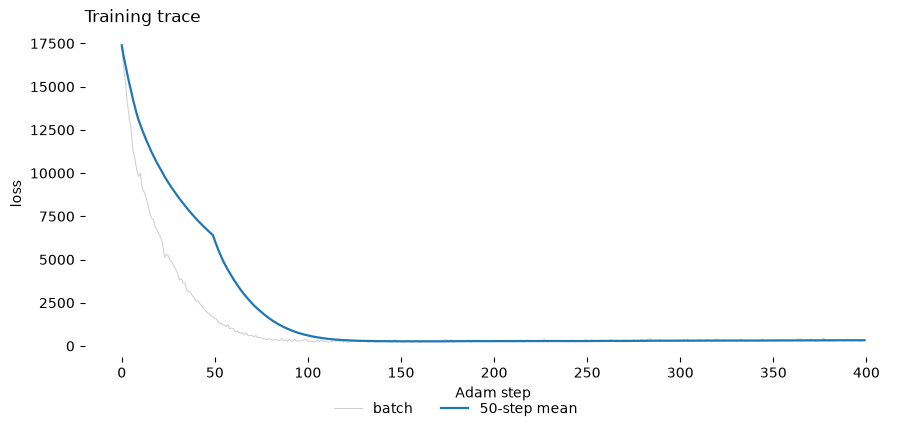

In [27]:
trace = pd.Series(minibatch_result.result)

figure, ax = plt.subplots(figsize=(9, 4))

ax.plot(trace.index, trace, color="0.8", linewidth=0.7, label="batch")
ax.plot(trace.index, trace.rolling(50, min_periods=1).mean(), color="C0", linewidth=1.6, label="50-step mean")

ax.set_xlabel("Adam step")
ax.set_ylabel("loss")
ax.set_title("Training trace", loc="left")
ax.spines[["top", "right"]].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
figure.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=2, frameon=False)
plt.show()

## Why the backends disagree

The coefficients and the amplitude land in the same place on either backend; the lengthscales do not. Either the two compute different objectives, or the objective barely distinguishes the lengthscales and float32 noise decides where the optimizer stops. Profiling one against the other separates the two.

In [28]:
PROFILE_LENGTHSCALES = np.linspace(1.0, 15.0, 29)


def compile_loss(mode):
    """The training objective as a function of the shared parameters, with the update disabled.

    A zero learning rate leaves the parameters where they are put, so the step function reduces to
    an evaluation of the loss at whatever the shared variables hold.
    """
    model, svgp = build_model()
    with model:
        step, shared_params, shared_extras = compile_training_step(
            minibatch_elbo,
            svgp,
            pt.matrix("X", shape=(BATCH_CELLS, features.shape[1])),
            pt.vector("y", shape=(N_WINDOWS,)),
            model=model,
            learning_rate=0.0,
            compile_kwargs={"mode": mode},
        )

    return step, shared_params, {value_var.name: shared for value_var, shared in shared_params.items()}


# One batch, held fixed, so the two backends and every lengthscale see identical data.
batch_features, batch_counts = load_batch(np.random.default_rng(7), N_WINDOWS)

profile = {}
for mode in ("FAST_RUN", "MLX"):
    step, _, by_name = compile_loss(mode)
    for name, value in minibatch_trained.items():
        if f"{name}_log__" in by_name:
            by_name[f"{name}_log__"].set_value(np.asarray(np.log(value), dtype=FLOATX))
        elif name in by_name:
            by_name[name].set_value(np.asarray(value, dtype=FLOATX))

    losses = []
    for lengthscale in PROFILE_LENGTHSCALES:
        by_name["spatial_lengthscale_log__"].set_value(np.asarray(np.log(lengthscale), dtype=FLOATX))
        losses.append(float(step(batch_features, batch_counts)))
    profile[mode] = np.array(losses)

profile = pd.DataFrame(profile, index=pd.Index(PROFILE_LENGTHSCALES.round(2), name="spatial lengthscale (deg)"))
profile["difference"] = profile["MLX"] - profile["FAST_RUN"]
profile.iloc[::4].round(3)

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


,FAST_RUN,MLX,difference
spatial lengthscale (deg),,,
1.00,39479.92,39479.80,-0.13
3.00,39509.24,39509.21,-0.03
5.00,39525.67,39525.69,0.02
7.00,39533.51,39533.52,0.01
9.00,39538.18,39538.22,0.04
11.00,39541.47,39541.48,0.01
13.00,39544.03,39544.02,-0.00
15.00,39545.93,39545.93,-0.00


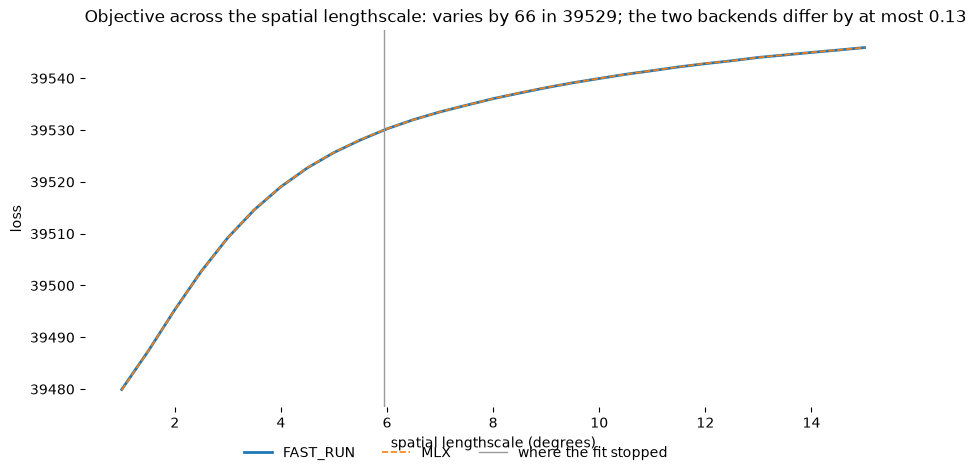

In [29]:
figure, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(profile.index, profile["FAST_RUN"], color="C0", linewidth=2.0, label="FAST_RUN")
ax.plot(profile.index, profile["MLX"], color="C1", linewidth=1.2, linestyle="--", label="MLX")
ax.axvline(minibatch_trained["spatial_lengthscale"], color="0.6", linewidth=1.0, label="where the fit stopped")

span = profile["FAST_RUN"].max() - profile["FAST_RUN"].min()
gap = profile["difference"].abs().max()
ax.set_title(
    f"Objective across the spatial lengthscale: varies by {span:.0f} in {profile['FAST_RUN'].mean():.0f}"
    f"; the two backends differ by at most {gap:.2f}",
    loc="left",
)
ax.set_xlabel("spatial lengthscale (degrees)")
ax.set_ylabel("loss")
ax.spines[["top", "right"]].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
figure.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=3, frameon=False)
plt.show()

### The field each backend found

Same objective, same data, same number of steps. What the flat lengthscale directions cost is visible here rather than in the parameter table.

In [19]:
backend_fits = {}
for mode in ("FAST_RUN", "MLX"):
    COMPILE_MODE = mode
    fitted_svgp, fitted_result = train_minibatch(400, n_windows=N_WINDOWS, learning_rate=0.02, seed=0)
    fitted_mean, _ = ptgp.predict(fitted_svgp, features, fitted_result)
    backend_fits[mode] = {"latent": fitted_mean.reshape(n_years, n_cells), "params": fitted_result.params}

COMPILE_MODE = "MLX"

pd.DataFrame(
    {
        mode: {
            **dict(zip(COVARIATE_NAMES, fit["params"]["coefficients"], strict=True)),
            "intercept": fit["params"]["intercept"],
            "amplitude": fit["params"]["amplitude"],
            "spatial lengthscale (deg)": fit["params"]["spatial_lengthscale"],
            "temporal lengthscale (yr)": fit["params"]["temporal_lengthscale"],
        }
        for mode, fit in backend_fits.items()
    }
).round(3)

adam:   0%|          | 0/400 [00:00<?, ?it/s]

/Users/jessegrabowski/Documents/Python/climate-risk/.pixi/envs/notebooks/lib/python3.12/functools.py:912: UserWarning: Skipping `Assert` Op (assertion: Could not broadcast dimensions. Broadcasting is only allowed along axes that have a statically known length 1. Use `specify_broadcastable` to inform PyTensor of a known shape.) as MLX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


adam:   0%|          | 0/400 [00:00<?, ?it/s]

,FAST_RUN,MLX
log km to river,0.46,0.45
log km to coast,-0.14,-0.14
intercept,-10.90,-10.89
amplitude,1.95,1.98
spatial lengthscale (deg),10.44,5.88
temporal lengthscale (yr),69.32,35.83


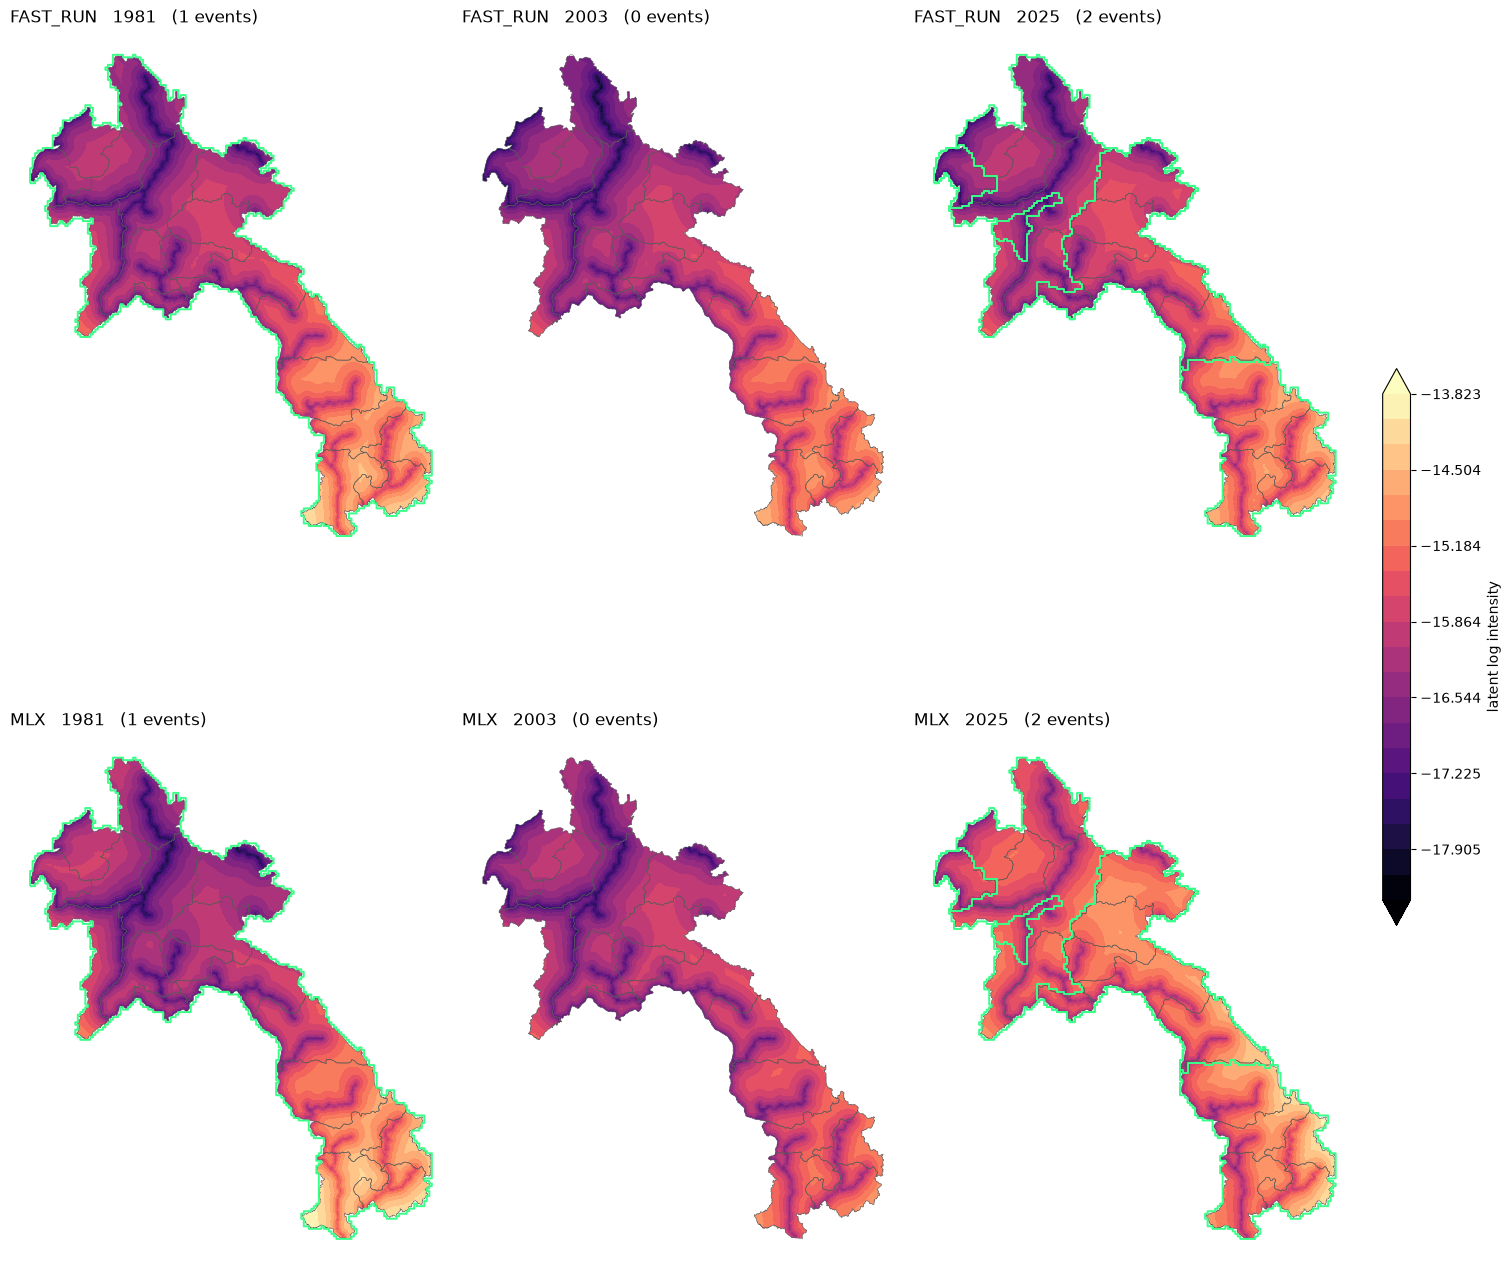

In [20]:
shown_years = [year_index[year] for year in PANEL_YEARS]
stacked = np.concatenate([fit["latent"][shown_years] for fit in backend_fits.values()])
levels = np.linspace(stacked.min(), stacked.max(), 21)

figure, axes = plt.subplots(2, 3, figsize=(15, 14), sharex=True, sharey=True)

for row, (mode, fit) in zip(axes, backend_fits.items(), strict=True):
    for ax, year in zip(row, PANEL_YEARS, strict=True):
        field, n_observed = draw_field(ax, fit["latent"][year_index[year]], levels, year)
        ax.set_title(f"{mode}   {year}   ({n_observed} events)", loc="left")

figure.colorbar(field, ax=axes, label="latent log intensity", shrink=0.4, pad=0.02)
plt.show()